<a href="https://colab.research.google.com/github/unsajamil/Dataset/blob/main/ICS451_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Dataset Loading

In [1]:
import nltk
import pandas as pd

##1.1 Downloading NLTK Resources

In [2]:
nltk.download('gutenberg')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

##1.2 Importing Libraries

In [3]:
from nltk.corpus import gutenberg, stopwords
from nltk.tokenize import word_tokenize
import re
from nltk.stem import PorterStemmer, WordNetLemmatizer
from collections import Counter
import matplotlib.pyplot as plt

##1.3 Loading Alice in Wonderland Text

In [4]:
alice_text = gutenberg.raw('carroll-alice.txt')
print(alice_text[:500])

[Alice's Adventures in Wonderland by Lewis Carroll 1865]

CHAPTER I. Down the Rabbit-Hole

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into the
book her sister was reading, but it had no pictures or conversations in
it, 'and what is the use of a book,' thought Alice 'without pictures or
conversation?'

So she was considering in her own mind (as well as she could, for the
hot day made her feel very sleepy an


#2. Text Preprocessing

##2.1 Cleaning Text Using Regular Expressions

In [5]:
clean_text = re.sub(r'[^A-Za-z0-9\s]', '', alice_text)

##2.2 Converting to Lowercase

In [6]:
clean_text = clean_text.lower()

##2.3 Tokenizing the Words

In [7]:
tokens = re.findall(r'\b\w+\b', clean_text)
print(tokens[:50])

['alices', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', '1865', 'chapter', 'i', 'down', 'the', 'rabbithole', 'alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting', 'by', 'her', 'sister', 'on', 'the', 'bank', 'and', 'of', 'having', 'nothing', 'to', 'do', 'once', 'or', 'twice', 'she', 'had', 'peeped', 'into', 'the', 'book', 'her', 'sister', 'was', 'reading', 'but', 'it', 'had']


##2.4 Removing the Stopwords

In [8]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word not in stop_words]
print(filtered_tokens[:50])

[nltk_data] Downloading package stopwords to /root/nltk_data...


['alices', 'adventures', 'wonderland', 'lewis', 'carroll', '1865', 'chapter', 'rabbithole', 'alice', 'beginning', 'get', 'tired', 'sitting', 'sister', 'bank', 'nothing', 'twice', 'peeped', 'book', 'sister', 'reading', 'pictures', 'conversations', 'use', 'book', 'thought', 'alice', 'without', 'pictures', 'conversation', 'considering', 'mind', 'well', 'could', 'hot', 'day', 'made', 'feel', 'sleepy', 'stupid', 'whether', 'pleasure', 'making', 'daisychain', 'would', 'worth', 'trouble', 'getting', 'picking', 'daisies']


[nltk_data]   Package stopwords is already up-to-date!


#3. Type-Token Ratio (TTR)

##3.1 Computing the TTR for Alice in Wonderland

In [9]:
unique_words = set(filtered_tokens)
total_words = len(filtered_tokens)
ttr = len(unique_words) / total_words
print("Total tokens:", total_words)
print("Unique words:", len(unique_words))
print("Type-Token Ratio (TTR):", ttr)

Total tokens: 12624
Unique words: 2625
Type-Token Ratio (TTR): 0.20793726235741444


#4. Compare Type-Token Ratio (TTR) Across Books

##4.1 Computing the TTR for Selected Books

In [10]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    clean_text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    clean_text = clean_text.lower()
    tokens = re.findall(r'\b\w+\b', clean_text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return filtered_tokens

def compute_ttr(tokens):
    return len(set(tokens)) / len(tokens)

books = ['shakespeare-hamlet.txt', 'bryant-stories.txt', 'milton-paradise.txt', 'austen-emma.txt']

for book in books:
    text = gutenberg.raw(book)
    tokens = preprocess_text(text)
    ttr = compute_ttr(tokens)
    print(f"Book: {book}")
    print(f"Total tokens: {len(tokens)}")
    print(f"Unique words: {len(set(tokens))}")
    print(f"TTR: {ttr}\n")

Book: shakespeare-hamlet.txt
Total tokens: 15880
Unique words: 4694
TTR: 0.2955919395465995



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Book: bryant-stories.txt
Total tokens: 21716
Unique words: 3889
TTR: 0.17908454595689813

Book: milton-paradise.txt
Total tokens: 45230
Unique words: 9198
TTR: 0.2033606013707716

Book: austen-emma.txt
Total tokens: 72903
Unique words: 9187
TTR: 0.12601676199882034



#5. Finding the Longest Words in Each Book

In [11]:
books = ['carroll-alice.txt', 'shakespeare-hamlet.txt', 'bryant-stories.txt', 'milton-paradise.txt', 'austen-emma.txt']

def preprocess_text(text):
    clean_text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    clean_text = clean_text.lower()
    tokens = re.findall(r'\b\w+\b', clean_text)
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return filtered_tokens

for book in books:
    text = gutenberg.raw(book)
    tokens = preprocess_text(text)
    longest_word = max(tokens, key=len)
    print(f"Book: {book}")
    print(f"Longest word: {longest_word}\n")

Book: carroll-alice.txt
Longest word: importantunimportantunimportantimportant

Book: shakespeare-hamlet.txt
Longest word: pastoricallcomicallhistoricallpastorall

Book: bryant-stories.txt
Longest word: imitaterightinthemiddleofeveryone

Book: milton-paradise.txt
Longest word: hiskithetmroboscis

Book: austen-emma.txt
Longest word: friendshipindignationabominable



#6. Stemming vs Lemmatization: Finding Maximum Differences

##6.1 Initializing the Stemmer and Lemmatizer

In [12]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

##6.2 Defining the Function to Compute Minimum Edit Distance

In [13]:
def min_edit_distance(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0]*(n+1) for _ in range(m+1)]

    for i in range(m+1):
        dp[i][0] = i
    for j in range(n+1):
        dp[0][j] = j

    for i in range(1,m+1):
        for j in range(1,n+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])

    return dp[m][n]

##6.3 Defining the Function to Find Top 10 Differences

In [14]:
def top_diff_words(tokens):
    differences = []
    for word in set(tokens):
        stemmed = stemmer.stem(word)
        lemmatized = lemmatizer.lemmatize(word)
        distance = min_edit_distance(stemmed, lemmatized)
        differences.append((word, stemmed, lemmatized, distance))

    differences.sort(key=lambda x: x[3], reverse=True)
    return differences[:10]

##6.4 Applying to All the 5 Books

In [15]:
books = ['carroll-alice.txt', 'shakespeare-hamlet.txt', 'bryant-stories.txt', 'milton-paradise.txt', 'austen-emma.txt']

def preprocess_text(text):
    clean_text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    clean_text = clean_text.lower()
    tokens = re.findall(r'\b\w+\b', clean_text)
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return filtered_tokens

for book in books:
    text = gutenberg.raw(book)
    tokens = preprocess_text(text)
    top_diff = top_diff_words(tokens)
    print(f"Book: {book}")
    for word, stemmed, lemmatized, distance in top_diff:
        print(f"Word: {word}, Stemmed: {stemmed}, Lemmatized: {lemmatized}, Distance: {distance}")
    print("\n")

Book: carroll-alice.txt
Word: uglification, Stemmed: uglif, Lemmatized: uglification, Distance: 7
Word: multiplication, Stemmed: multipl, Lemmatized: multiplication, Distance: 7
Word: diligently, Stemmed: dilig, Lemmatized: diligently, Distance: 5
Word: usurpation, Stemmed: usurp, Lemmatized: usurpation, Distance: 5
Word: cheerfully, Stemmed: cheer, Lemmatized: cheerfully, Distance: 5
Word: explanation, Stemmed: explan, Lemmatized: explanation, Distance: 5
Word: accusation, Stemmed: accus, Lemmatized: accusation, Distance: 5
Word: immediately, Stemmed: immedi, Lemmatized: immediately, Distance: 5
Word: considering, Stemmed: consid, Lemmatized: considering, Distance: 5
Word: conversation, Stemmed: convers, Lemmatized: conversation, Distance: 5


Book: shakespeare-hamlet.txt
Word: cheerefully, Stemmed: cheer, Lemmatized: cheerefully, Distance: 6
Word: tyrannically, Stemmed: tyrann, Lemmatized: tyrannically, Distance: 6
Word: imaginations, Stemmed: imagin, Lemmatized: imagination, Distanc

#7. Frequency of Lemmatized Words and Visualization

##7.1 Initializing the Lemmatizer

In [16]:
lemmatizer = WordNetLemmatizer()

##7.2 Defining the Preprocessing Function

In [17]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    clean_text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    clean_text = clean_text.lower()
    tokens = re.findall(r'\b\w+\b', clean_text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]
    return lemmatized_tokens


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


##7.3 Computing the Frequencies and Ploting Top 10 Words

[('said', 462), ('alice', 385), ('little', 128), ('one', 103), ('know', 88), ('like', 86), ('would', 83), ('went', 83), ('could', 77), ('thing', 77)] 



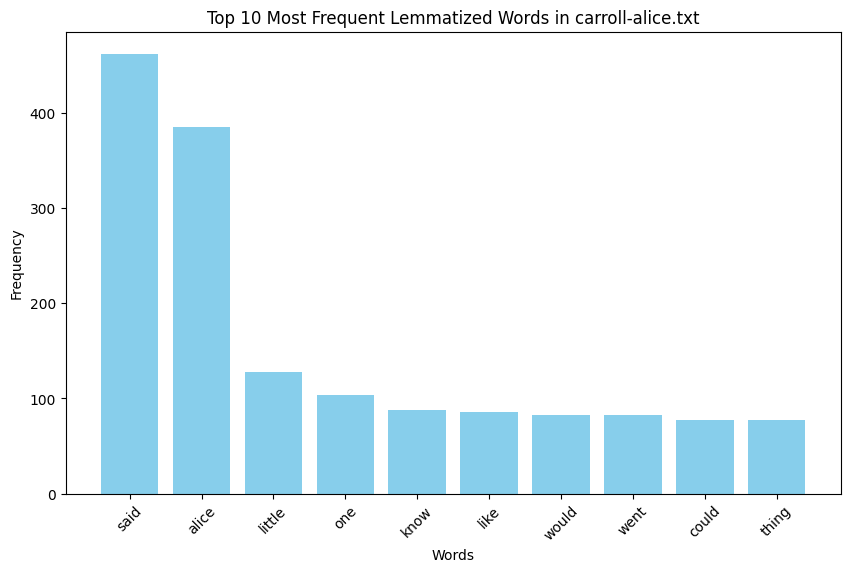



[('ham', 337), ('lord', 217), ('king', 180), ('haue', 175), ('come', 127), ('hamlet', 107), ('let', 107), ('shall', 107), ('thou', 105), ('good', 98)] 



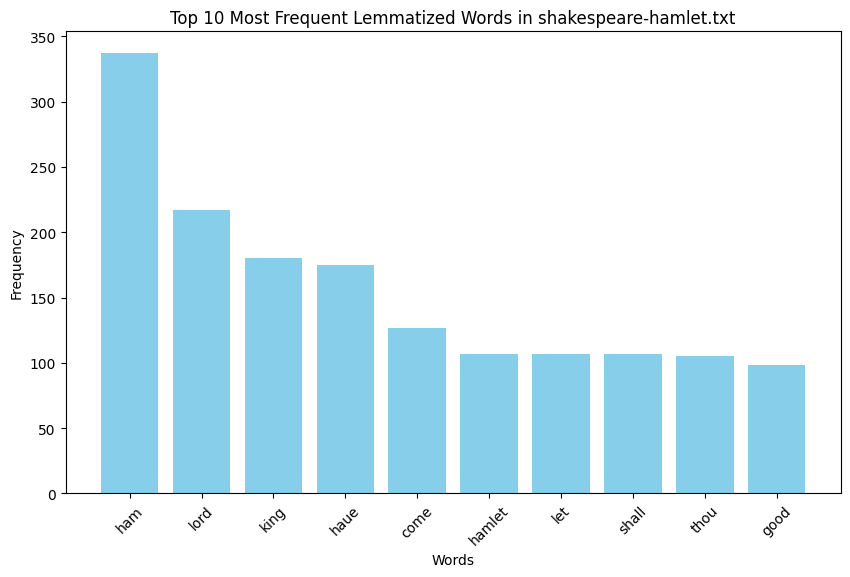



[('little', 597), ('said', 453), ('came', 191), ('one', 187), ('could', 158), ('king', 135), ('went', 122), ('would', 112), ('great', 110), ('time', 108)] 



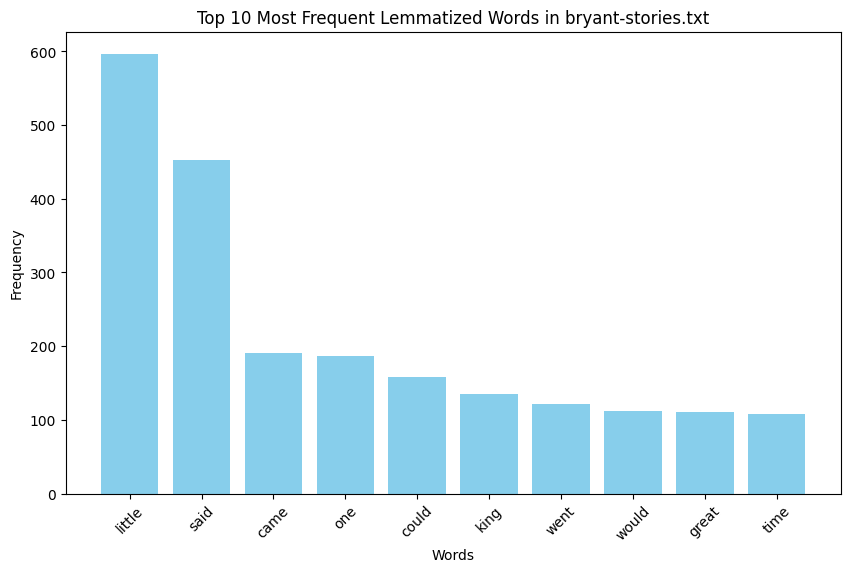



[('thou', 432), ('heaven', 423), ('thy', 414), ('thee', 357), ('thus', 317), ('god', 306), ('shall', 283), ('yet', 223), ('though', 216), ('earth', 215)] 



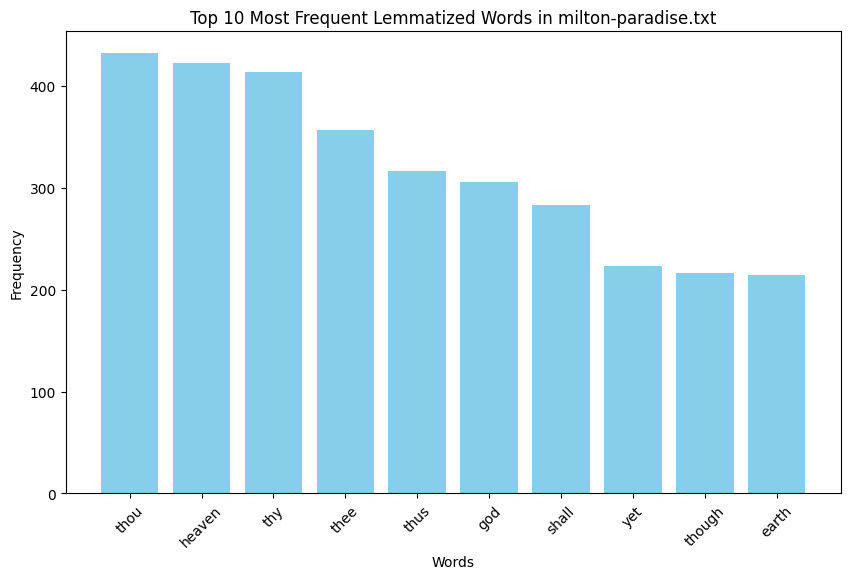



[('mr', 1811), ('could', 830), ('would', 817), ('emma', 751), ('miss', 588), ('must', 567), ('much', 474), ('said', 474), ('thing', 447), ('one', 442)] 



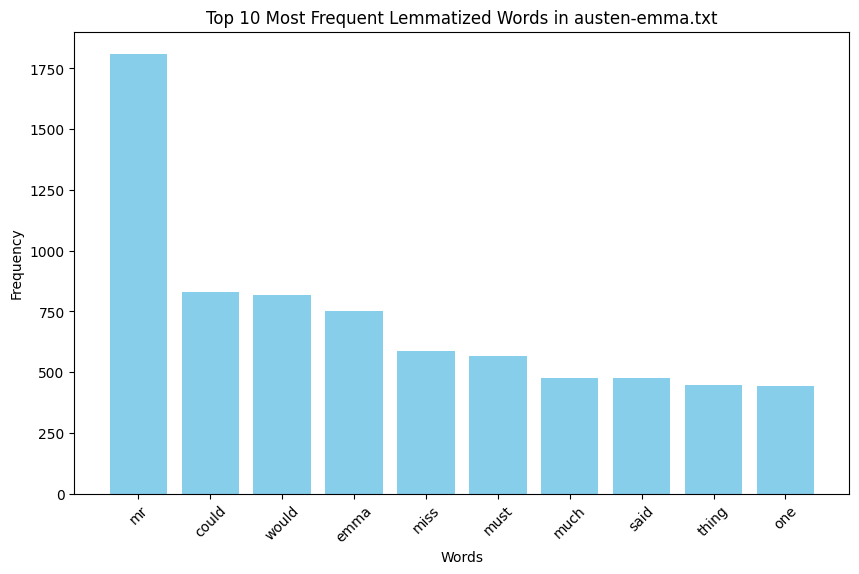

In [18]:
books = ['carroll-alice.txt', 'shakespeare-hamlet.txt', 'bryant-stories.txt', 'milton-paradise.txt', 'austen-emma.txt']

for book in books:
    text = gutenberg.raw(book)
    tokens = preprocess_text(text)
    freq_dist = Counter(tokens)
    top_10 = freq_dist.most_common(10)
    print(top_10, "\n")

    words, counts = zip(*top_10)
    plt.figure(figsize=(10,6))
    plt.bar(words, counts, color='skyblue')
    plt.title(f'Top 10 Most Frequent Lemmatized Words in {book}')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()
    print("\n")

#8.Applying N-gram Models to the Amazon Fine Food Reviews Dataset

##8.1 Loading the Dataset

In [20]:
df = pd.read_csv("Reviews.csv")
sample_df = df.sample(n=10000, random_state=42)
reviews = sample_df["Text"]
reviews.head()

,Text
165256,Having tried a couple of other brands of glute...
231465,My cat loves these treats. If ever I can't fin...
427827,A little less than I expected. It tends to ha...
433954,"First there was Frosted Mini-Wheats, in origin..."
70260,and I want to congratulate the graphic artist ...


##8.2 Text Preprocessing for N-gram Model Construction

In [22]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

processed_reviews = reviews.apply(preprocess)
processed_reviews.head()

,Text
165256,"[tried, couple, brands, glutenfree, sandwich, ..."
231465,"[cat, loves, treats, ever, cant, find, house, ..."
427827,"[little, less, expected, tends, muddy, taste, ..."
433954,"[first, frosted, miniwheats, original, size, f..."
70260,"[want, congratulate, graphic, artist, putting,..."


#9.Constructing Bigram and Trigram Models

##9.1 Flatten All Reviews into One Token List

In [24]:
from itertools import chain

all_tokens = list(chain.from_iterable(processed_reviews))
print("Total tokens:", len(all_tokens))

Total tokens: 406008


##9.2 Generate Bigrams and Trigrams

In [25]:
from nltk.util import ngrams

bigrams = list(ngrams(all_tokens, 2))
trigrams = list(ngrams(all_tokens, 3))

print("Total bigrams:", len(bigrams))
print("Total trigrams:", len(trigrams))

Total bigrams: 406007
Total trigrams: 406006


##9.3 Compute Frequency Distributions

In [26]:
from collections import Counter

bigram_freq = Counter(bigrams)
trigram_freq = Counter(trigrams)

print("Top 10 Bigrams:")
print(bigram_freq.most_common(10))

Top 10 Bigrams:
[(('taste', 'like'), 258), (('peanut', 'butter'), 248), (('highly', 'recommend'), 235), (('ive', 'tried'), 231), (('dog', 'food'), 226), (('much', 'better'), 225), (('grocery', 'store'), 202), (('green', 'tea'), 197), (('tastes', 'like'), 188), (('dont', 'know'), 180)]


In [27]:
print("\nTop 10 Trigrams:")
print(trigram_freq.most_common(10))


Top 10 Trigrams:
[(('local', 'grocery', 'store'), 44), (('health', 'food', 'store'), 36), (('would', 'highly', 'recommend'), 35), (('cant', 'go', 'wrong'), 28), (('highly', 'recommend', 'product'), 27), (('local', 'health', 'food'), 26), (('would', 'recommend', 'anyone'), 25), (('chocolate', 'chip', 'cookies'), 25), (('would', 'definitely', 'recommend'), 25), (('bobs', 'red', 'mill'), 23)]


#10.Calculating Perplexity for Bigram and Trigram Models

##10.1 Preparing the Test Sentence

In [28]:
test_sentence = "I enjoyed the meal, but the service was slow"

def preprocess_sentence(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r'[^a-zA-Z\s]', '', sentence)
    tokens = word_tokenize(sentence)
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

test_tokens = preprocess_sentence(test_sentence)
print("Processed Test Tokens:", test_tokens)

Processed Test Tokens: ['enjoyed', 'meal', 'service', 'slow']


##10.2 Defining the Function for Bigram and Trigram Probability with Laplace Smoothing

In [29]:
def ngram_prob(tokens, ngram_freq, n_minus1_freq, n):
    V = len(set(all_tokens))
    prob = 1.0
    for i in range(n-1, len(tokens)):
        ngram_tuple = tuple(tokens[i-n+1:i+1])
        count_ngram = ngram_freq.get(ngram_tuple, 0)
        count_n_minus1 = n_minus1_freq.get(tuple(tokens[i-n+1:i]), 0)
        prob *= (count_ngram + 1) / (count_n_minus1 + V)
    return prob

##10.3 Calculating the Perplexity

In [30]:
import math

bigram_minus1_freq = Counter([tuple([t]) for t in all_tokens])
trigram_minus1_freq = Counter(list(ngrams(all_tokens, 2)))

P_bigram = ngram_prob(test_tokens, bigram_freq, bigram_minus1_freq, 2)
perplexity_bigram = P_bigram ** (-1/len(test_tokens))

P_trigram = ngram_prob(test_tokens, trigram_freq, trigram_minus1_freq, 3)
perplexity_trigram = P_trigram ** (-1/len(test_tokens))

print("Bigram Perplexity:", perplexity_bigram)
print("Trigram Perplexity:", perplexity_trigram)

Bigram Perplexity: 2029.367147592902
Trigram Perplexity: 159.69345634683972


#11.Word Cloud Visualization of Top Bigrams and Trigrams

##11.1 Preparing the Bigrams and Trigrams for Word Cloud

In [31]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

bigram_strings = ['_'.join(bigram) for bigram, freq in bigram_freq.most_common(100)]

trigram_strings = ['_'.join(trigram) for trigram, freq in trigram_freq.most_common(100)]

##11.2 Generating the Word Cloud for Bigrams

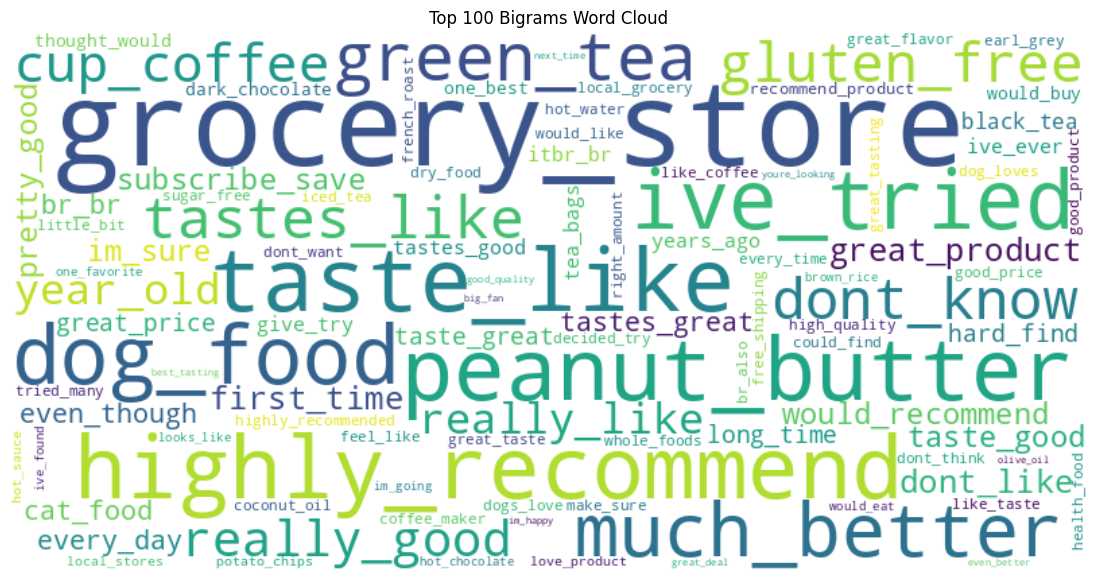

In [32]:
bigram_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(bigram_strings))

plt.figure(figsize=(15,7))
plt.imshow(bigram_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 100 Bigrams Word Cloud")
plt.show()

##11.3 Generating the Word Cloud for Trigrams

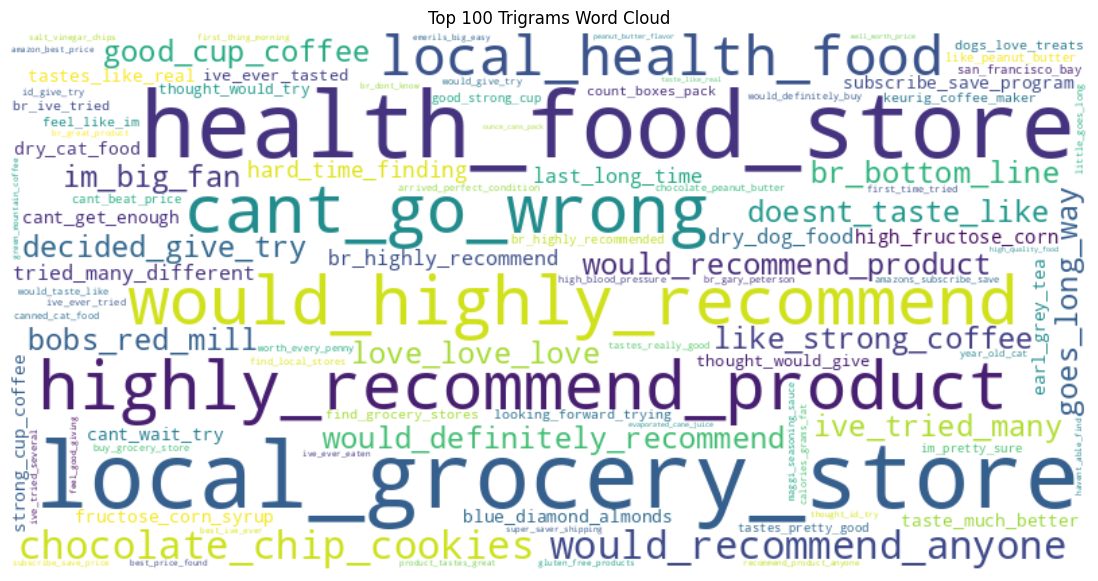

In [33]:
trigram_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(trigram_strings))

plt.figure(figsize=(15,7))
plt.imshow(trigram_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 100 Trigrams Word Cloud")
plt.show()